In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
import scipy.cluster.hierarchy as sch
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

In [8]:
cell_types=["Tcells","Bcells",	"Fibroblasts", "NKcells", "Macrophages","Mast cells", "DCs", "other", "Endothelial cells"]
target_CAFs=["FAP", "PDGFRA", "PDGFRB", "S100A4", "LRRC15", "IL1R1", "IL1R2","SMO"]
target_receptors_molecules=["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/filtered_fibroblasts_gene_exp_transposed_w_clinical.csv")
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")
df_cell_abundance = pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_bp_res_mid_lvl_ct_ct_fraction.csv")
fibr_gene_expression_cell_abundance=fibr_gene_expression_modified.merge(df_cell_abundance, on="dcc_filename", how="left")
fibr_gene_expression_cell_abundance.head(5)

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Endothelial cells,Roi,Segment_y,Sample_y,NACT_status,Annotation_cell,Roi.1,Segment_geomx,Patient_y,Site
0,DSP-1001660016604-A-A02.dcc,1.718431,2.137428,1.836881,1.997698,0.161226,2.480789,4.364810,2.270061,0.033787,...,0.028128,1,stroma,S130_iOme,post,CD8_Iba1,NaN,tsi,S130,Omentum
1,DSP-1001660016604-A-A04.dcc,1.622100,2.027326,1.737519,1.901971,0.158211,2.375319,5.534481,2.163770,0.033655,...,0.029949,2,stroma,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum
2,DSP-1001660016604-A-A05.dcc,1.427961,1.505719,1.830641,1.348903,0.165076,2.201253,5.497989,2.271254,0.033957,...,0.029244,2,tumor,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum
3,DSP-1001660016604-A-A07.dcc,1.353614,1.787912,1.868598,1.631783,0.164922,2.126467,6.245903,2.308907,0.033950,...,0.029367,3,tumor,S130_iOme,post,CD4_CD8_CD11_Iba1,NaN,tsi,S130,Omentum
4,DSP-1001660016604-A-A08.dcc,1.829375,1.602863,1.291572,1.448092,0.164608,1.941802,3.836590,1.731314,0.033936,...,0.029515,4,stroma,S130_iOme,post,CD4_CD11,NaN,tsi,S130,Omentum


In [9]:
fibr_gene_expression_cell_abundance["PFS_HL_group"] = fibr_gene_expression_cell_abundance["PFS_quartile_b12"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)
fibr_gene_expression_cell_abundance["OS_HL_group"] = fibr_gene_expression_cell_abundance["OS_quartile_b12"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)


In [6]:
df_cell_abundance.head(2)

,dcc_filename,tumor,Tcells,Bcells,Fibroblasts,NKcells,Macrophages,Mast cells,DCs,other,Endothelial cells,Roi,Segment,Sample,NACT_status,Annotation_cell,Roi.1,Segment_geomx,Patient,Site
0,DSP-1001660016606-G-A02.dcc,0.476461,0.009487,0.135361,0.231508,0.018543,0.101739,0.001637,0.014749,NaN,0.010419,1,stroma,S053_post,post,posCD8_posIBA1,1.0,tsi,S053,Omentum
1,DSP-1001660016606-G-A03.dcc,0.806981,0.013774,0.026948,0.064725,0.012740,0.055951,0.001264,0.009905,NaN,0.007552,1,tumor,S053_post,post,posCD8_posIBA1,1.0,tsi,S053,Omentum


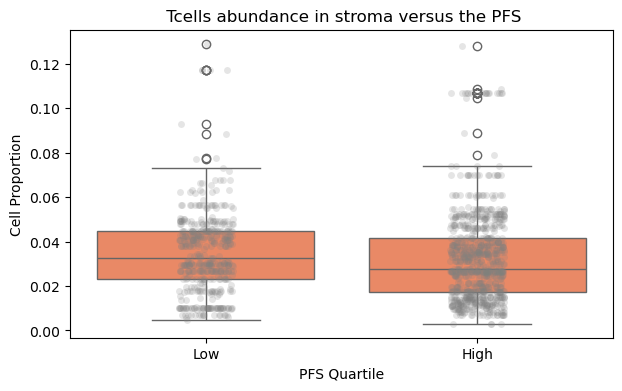

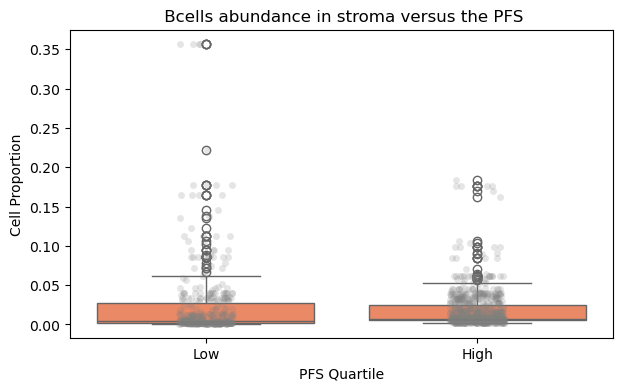

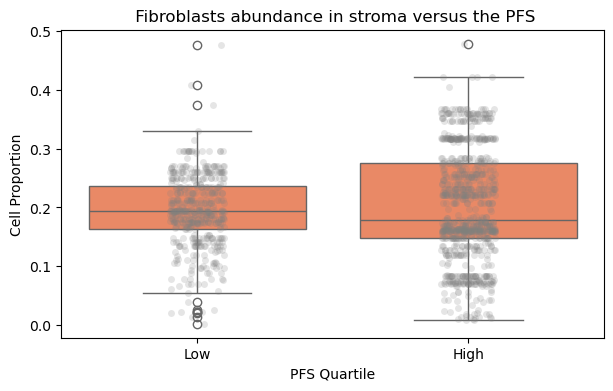

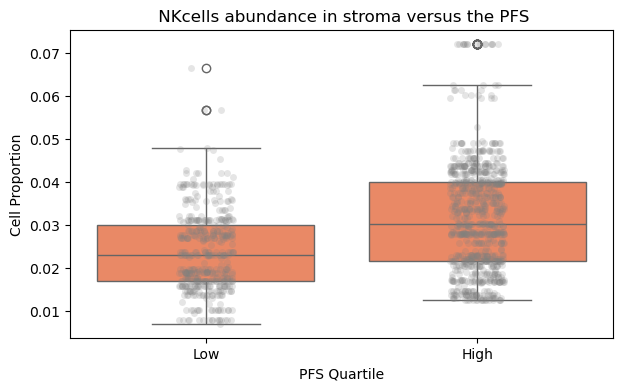

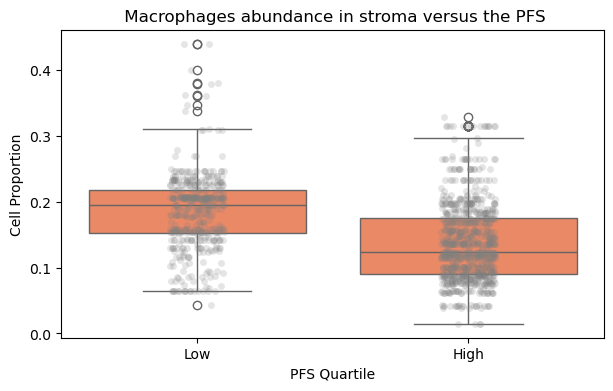

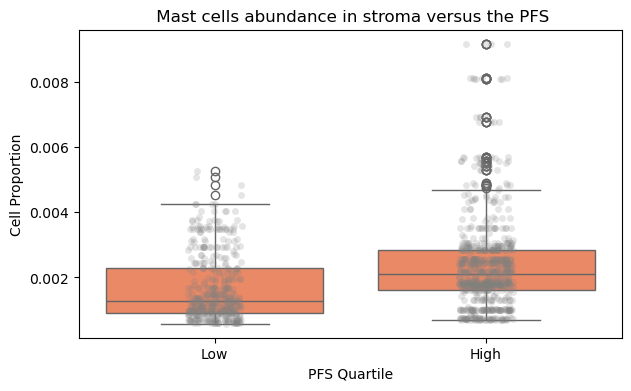

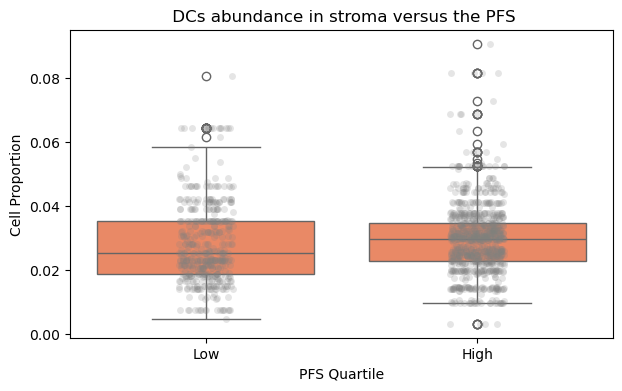

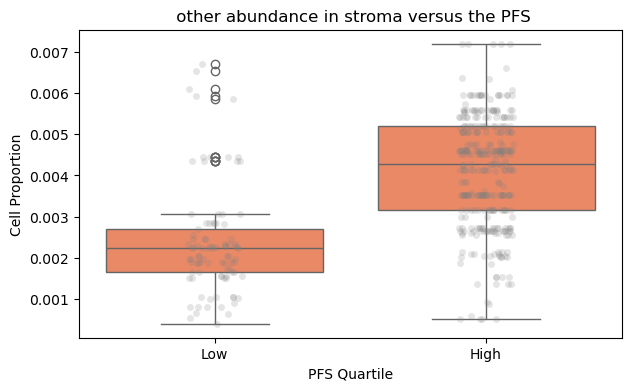

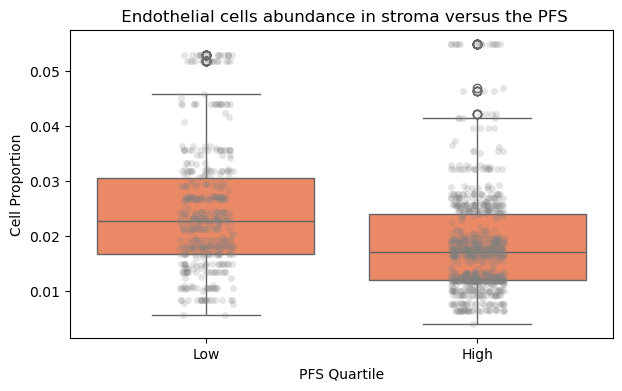

In [ ]:
fibr_gene_expression_cell_abundance_stroma=fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_y"]=="stroma"]
for cell in cell_types:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_HL_group",y=cell,data=fibr_gene_expression_cell_abundance_stroma, color='coral')
    sns.stripplot(x="PFS_HL_group", y=cell, data=fibr_gene_expression_cell_abundance_stroma, color='grey', alpha=0.2, jitter=True)
    plt.title(f" {cell} abundance in stroma versus the PFS")
    plt.xlabel("PFS group")
    plt.ylabel("Cell Proportion")
    plt.show()

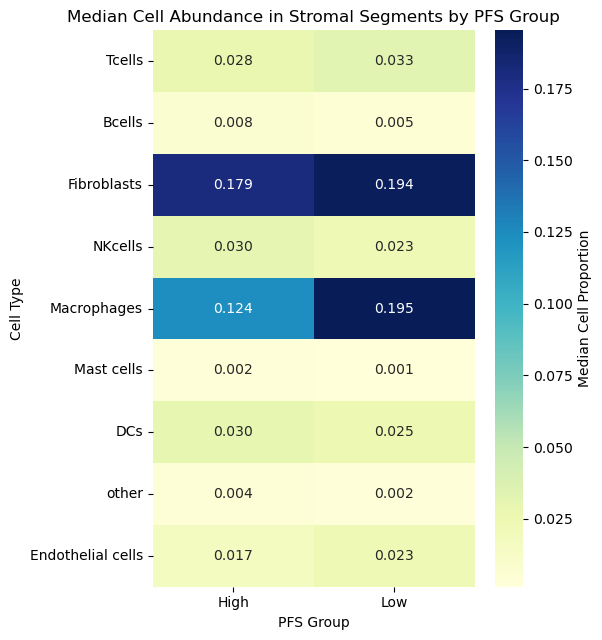

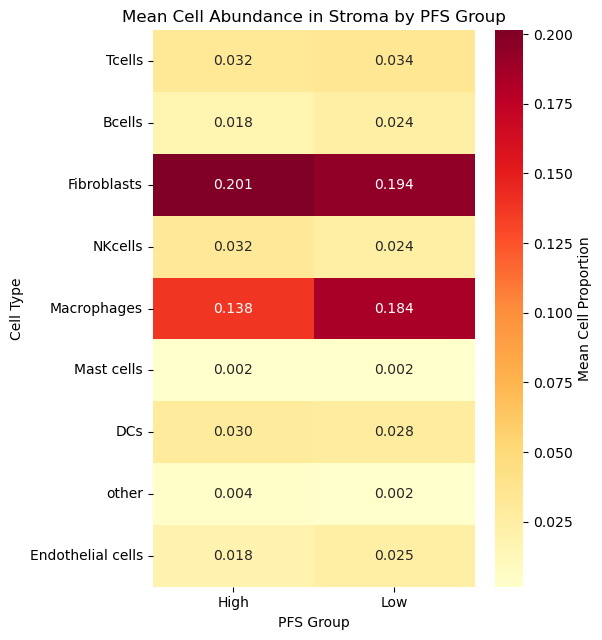

In [32]:

stroma_data = fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_y"] == "stroma"]

median_summary = stroma_data.groupby("PFS_HL_group")[cell_types].median().T
mean_summary = stroma_data.groupby("PFS_HL_group")[cell_types].mean().T

# Optional: rename columns if you want them capitalized or ordered
median_summary.columns.name = "PFS group"
mean_summary.columns.name = "PFS group"

# Plot median heatmap
plt.figure(figsize=(6, len(cell_types) * 0.5 + 2))
sns.heatmap(median_summary, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Median Cell Proportion'})
plt.title("Median Cell Abundance in Stromal Segments by PFS Group")
plt.xlabel("PFS Group")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

# Plot mean heatmap
plt.figure(figsize=(6, len(cell_types) * 0.5 + 2))
sns.heatmap(mean_summary, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={'label': 'Mean Cell Proportion'})
plt.title("Mean Cell Abundance in Stroma by PFS Group")
plt.xlabel("PFS Group")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

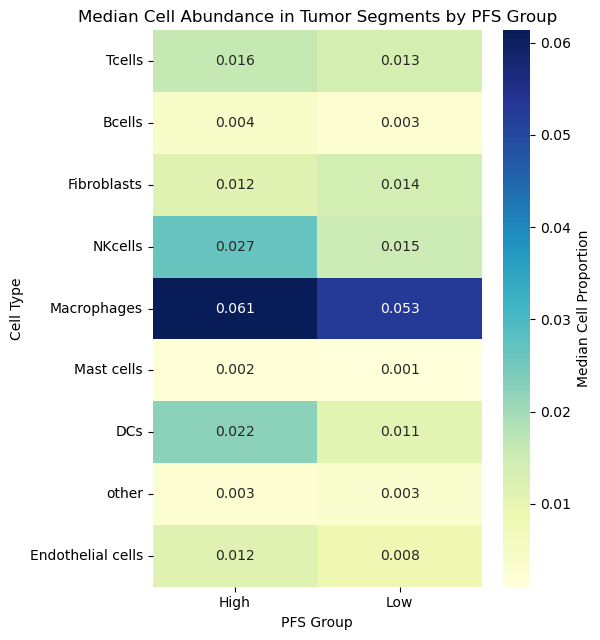

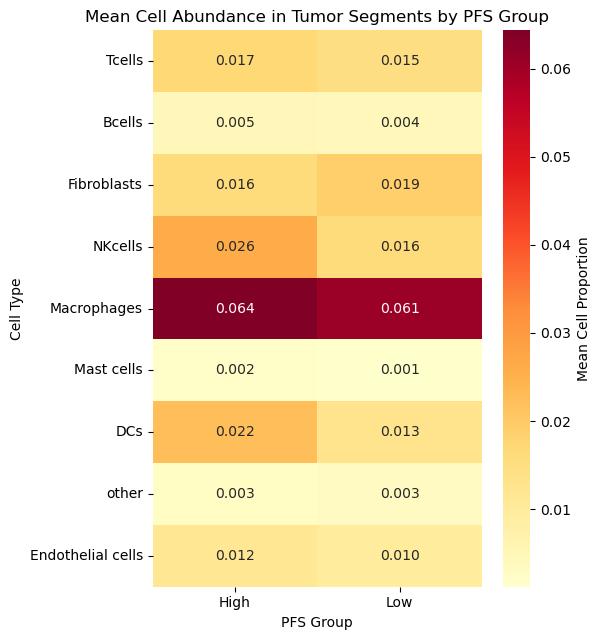

In [34]:
tumor_data = fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_y"] == "tumor"]

median_summary = tumor_data.groupby("PFS_HL_group")[cell_types].median().T
mean_summary = tumor_data.groupby("PFS_HL_group")[cell_types].mean().T

# Optional: rename columns if you want them capitalized or ordered
median_summary.columns.name = "PFS group"
mean_summary.columns.name = "PFS group"

# Plot median heatmap
plt.figure(figsize=(6, len(cell_types) * 0.5 + 2))
sns.heatmap(median_summary, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Median Cell Proportion'})
plt.title("Median Cell Abundance in Tumor Segments by PFS Group")
plt.xlabel("PFS Group")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

# Plot mean heatmap
plt.figure(figsize=(6, len(cell_types) * 0.5 + 2))
sns.heatmap(mean_summary, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={'label': 'Mean Cell Proportion'})
plt.title("Mean Cell Abundance in Tumor Segments by PFS Group")
plt.xlabel("PFS Group")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

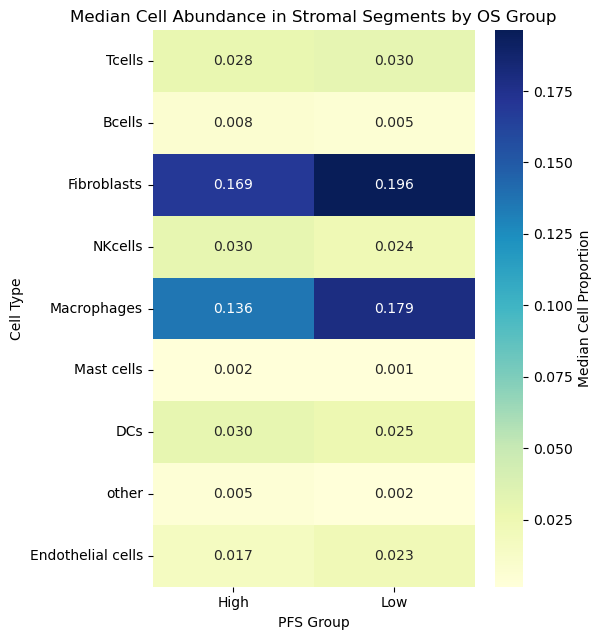

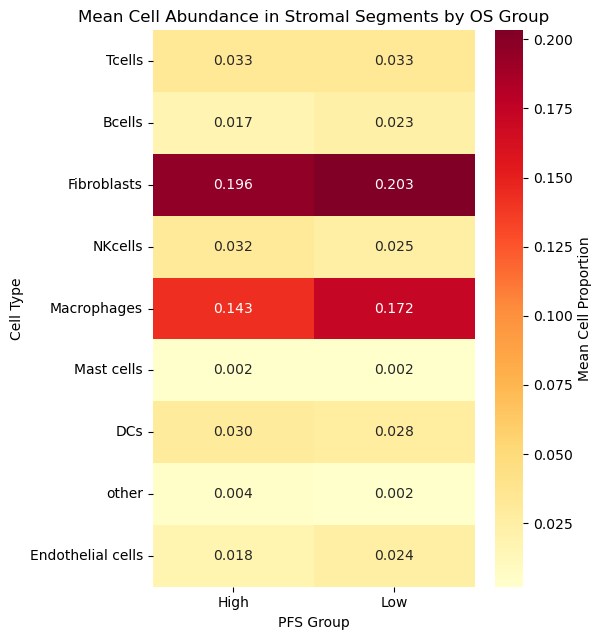

In [27]:
stroma_data = fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_y"] == "stroma"]

median_summary = stroma_data.groupby("OS_HL_group")[cell_types].median().T
mean_summary = stroma_data.groupby("OS_HL_group")[cell_types].mean().T

# Optional: rename columns if you want them capitalized or ordered
median_summary.columns.name = "OS group"
mean_summary.columns.name = "OS group"

# Plot median heatmap
plt.figure(figsize=(6, len(cell_types) * 0.5 + 2))
sns.heatmap(median_summary, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Median Cell Proportion'})
plt.title("Median Cell Abundance in Stromal Segments by OS Group")
plt.xlabel("PFS Group")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

# Plot mean heatmap
plt.figure(figsize=(6, len(cell_types) * 0.5 + 2))
sns.heatmap(mean_summary, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={'label': 'Mean Cell Proportion'})
plt.title("Mean Cell Abundance in Stromal Segments by OS Group")
plt.xlabel("PFS Group")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

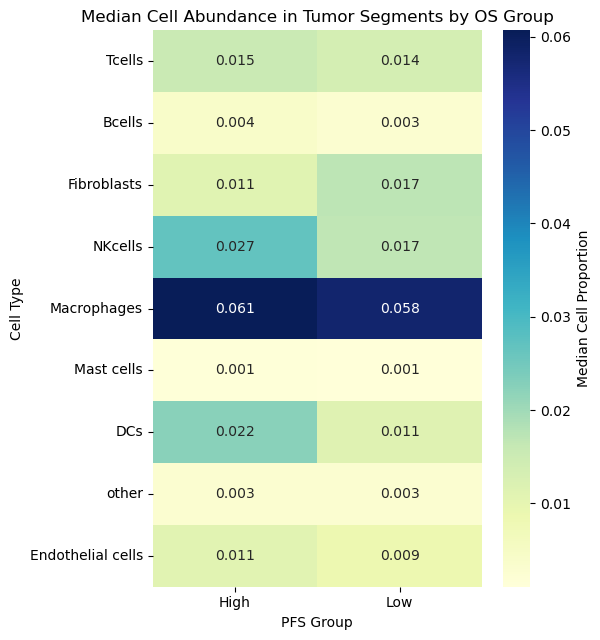

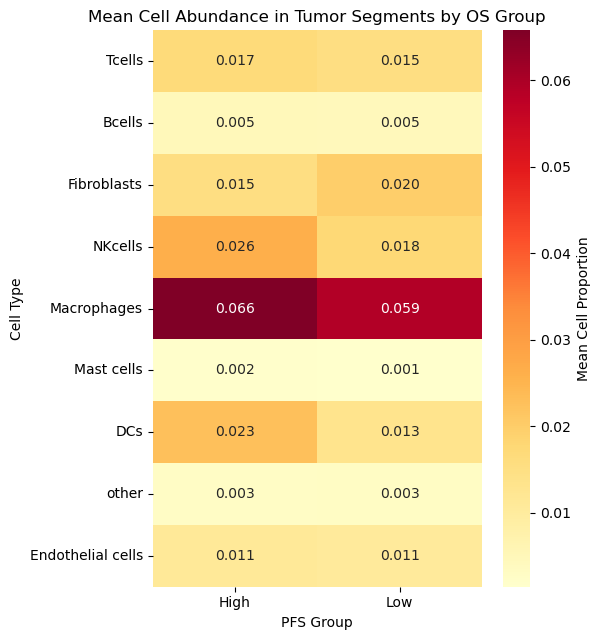

In [28]:
tumor_data = fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_y"] == "tumor"]

median_summary = tumor_data.groupby("OS_HL_group")[cell_types].median().T
mean_summary = tumor_data.groupby("OS_HL_group")[cell_types].mean().T

# Optional: rename columns if you want them capitalized or ordered
median_summary.columns.name = "OS group"
mean_summary.columns.name = "OS group"

# Plot median heatmap
plt.figure(figsize=(6, len(cell_types) * 0.5 + 2))
sns.heatmap(median_summary, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Median Cell Proportion'})
plt.title("Median Cell Abundance in Tumor Segments by OS Group")
plt.xlabel("PFS Group")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

# Plot mean heatmap
plt.figure(figsize=(6, len(cell_types) * 0.5 + 2))
sns.heatmap(mean_summary, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={'label': 'Mean Cell Proportion'})
plt.title("Mean Cell Abundance in Tumor Segments by OS Group")
plt.xlabel("PFS Group")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

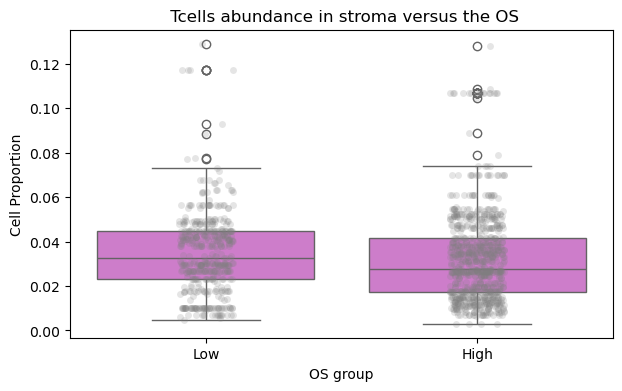

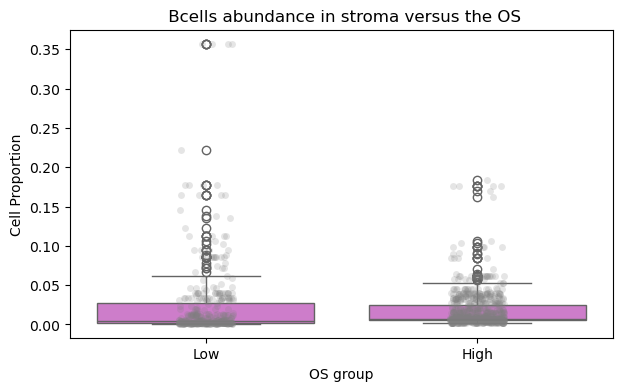

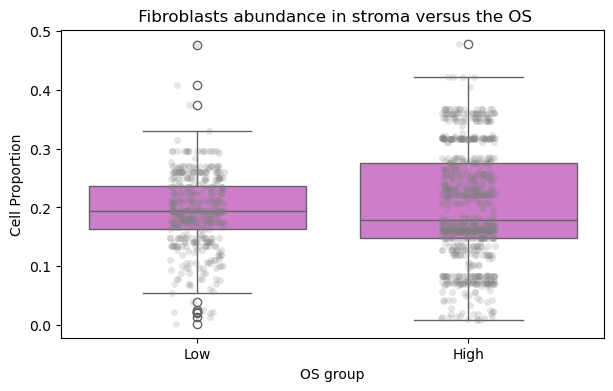

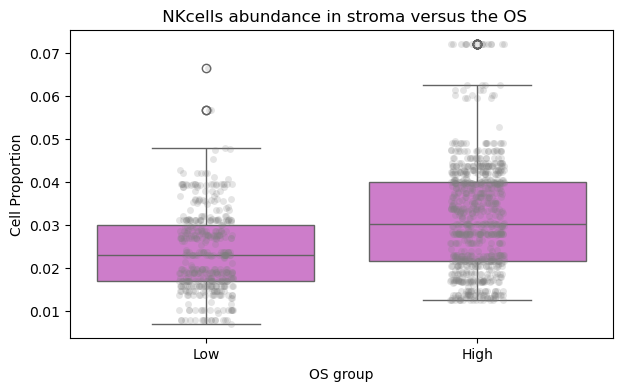

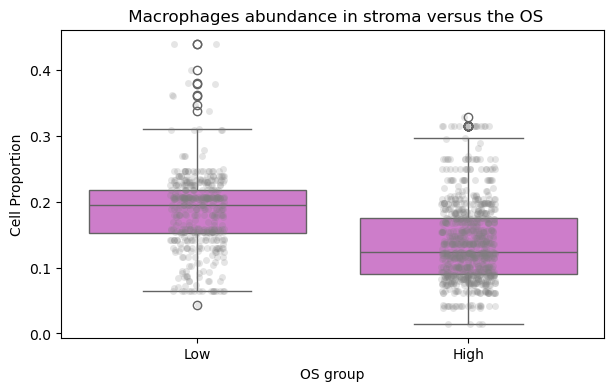

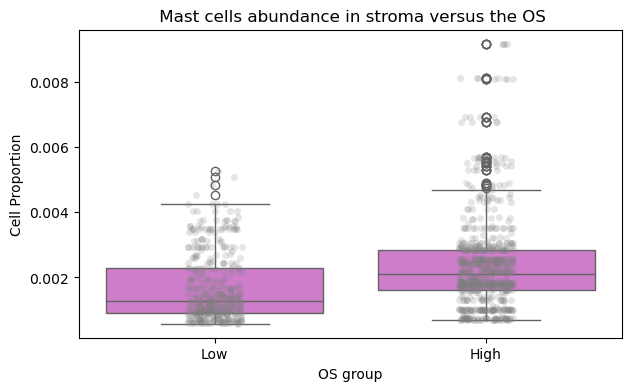

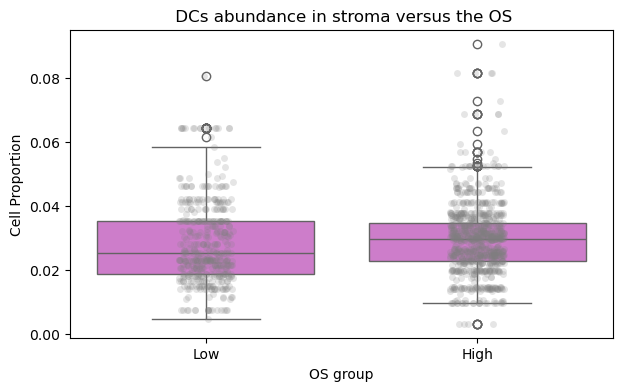

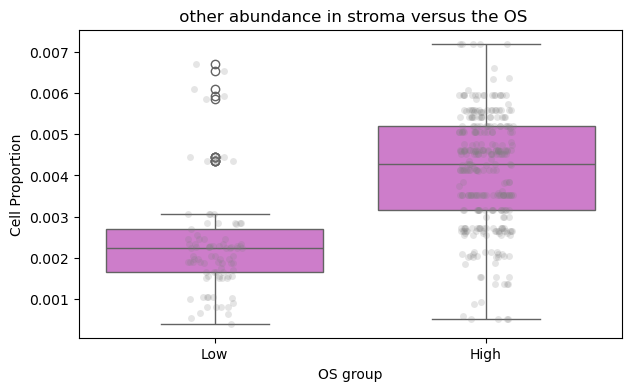

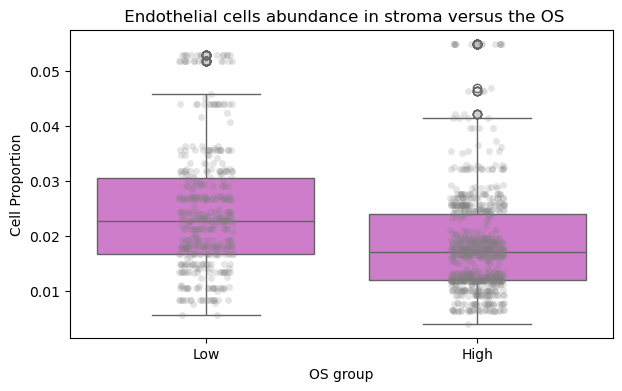

In [18]:
fibr_gene_expression_cell_abundance_stroma=fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_y"]=="stroma"]
for cell in cell_types:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_HL_group",y=cell,data=fibr_gene_expression_cell_abundance_stroma, color='orchid')
    sns.stripplot(x="PFS_HL_group", y=cell, data=fibr_gene_expression_cell_abundance_stroma, color='grey', alpha=0.2, jitter=True)
    plt.title(f" {cell} abundance in stroma versus the OS")
    plt.xlabel("OS group")
    plt.ylabel("Cell Proportion")
    plt.show()

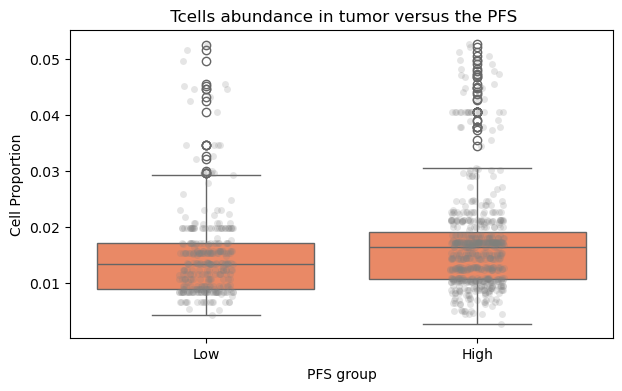

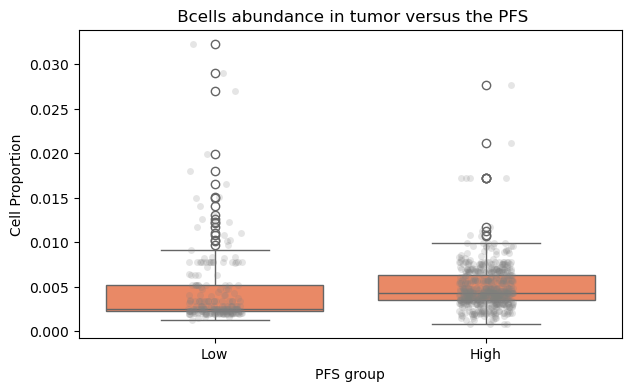

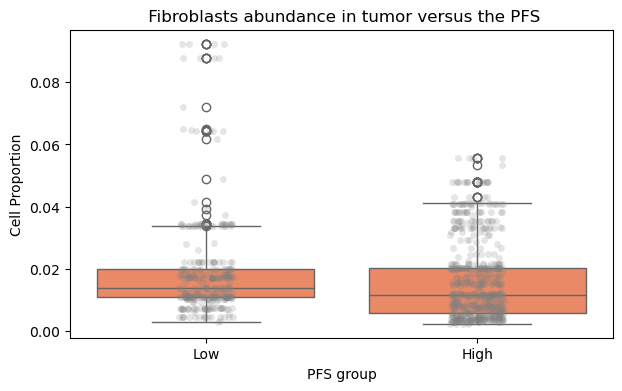

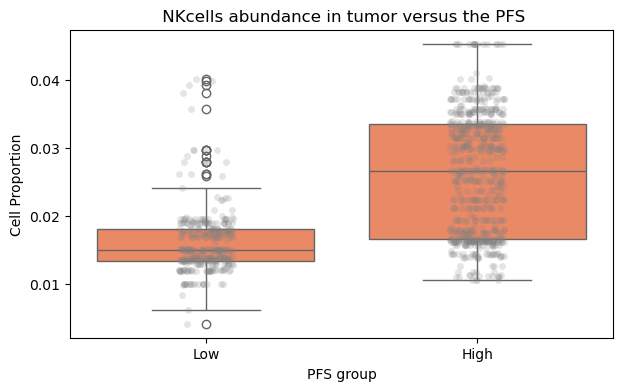

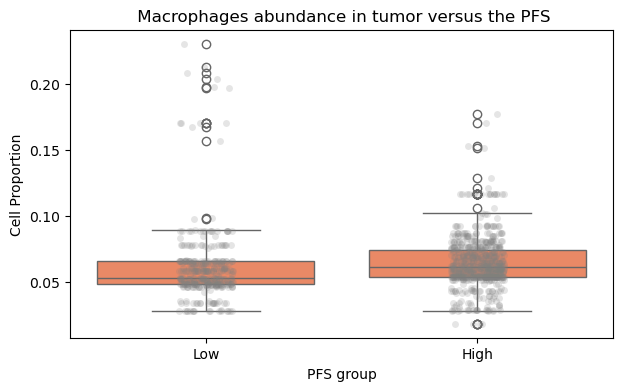

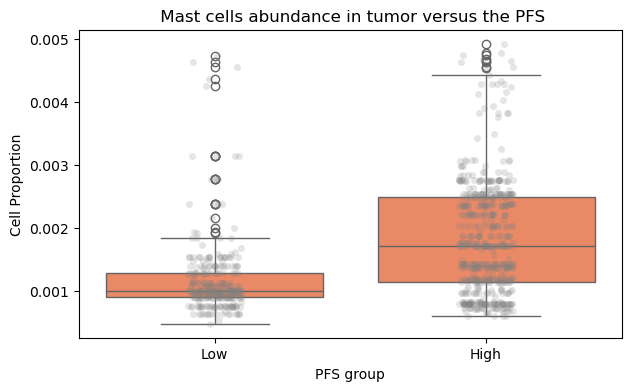

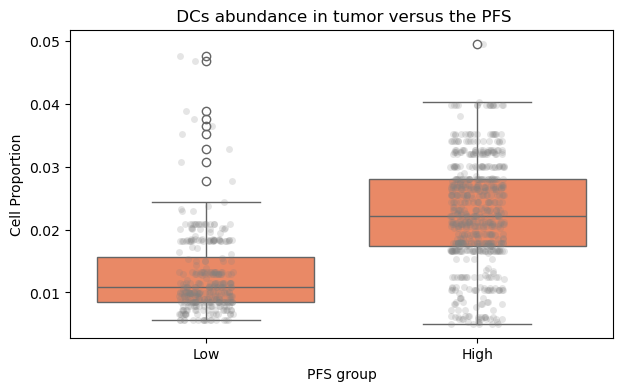

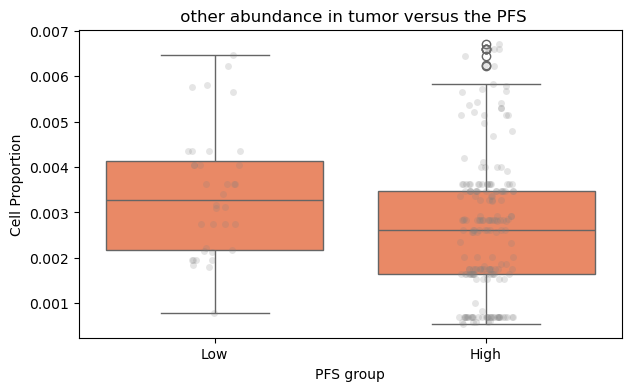

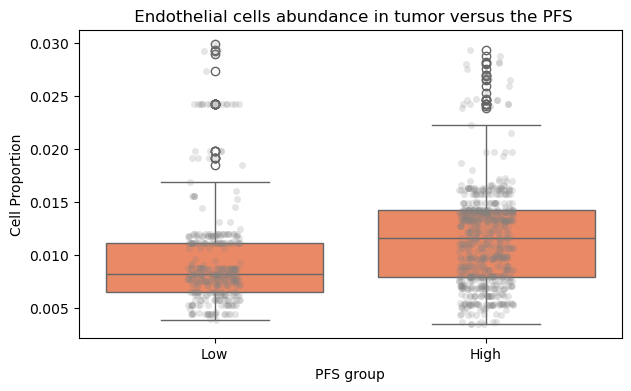

In [19]:
fibr_gene_expression_cell_abundance_stroma=fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_y"]=="tumor"]
for cell in cell_types:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_HL_group",y=cell,data=fibr_gene_expression_cell_abundance_stroma, color='coral')
    sns.stripplot(x="PFS_HL_group", y=cell, data=fibr_gene_expression_cell_abundance_stroma, color='grey', alpha=0.2, jitter=True)
    plt.title(f" {cell} abundance in tumor versus the PFS")
    plt.xlabel("PFS group")
    plt.ylabel("Cell Proportion")
    plt.show()

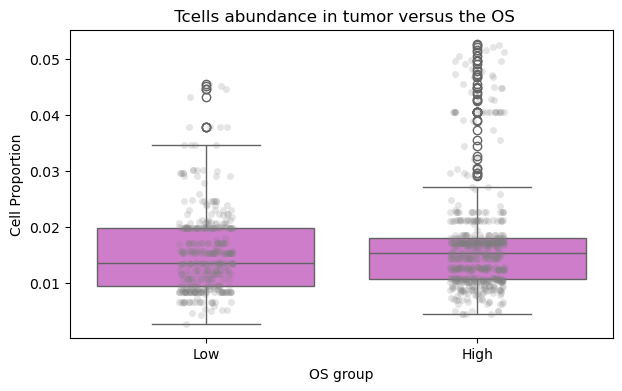

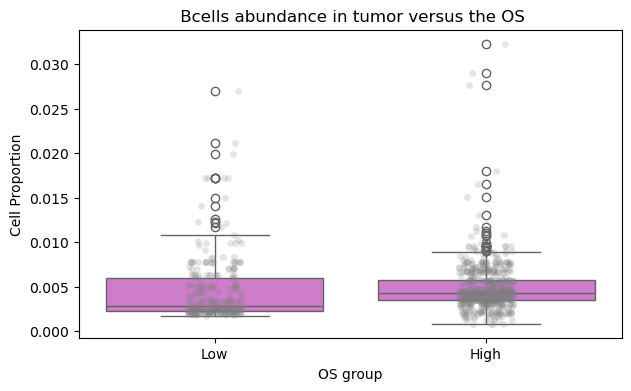

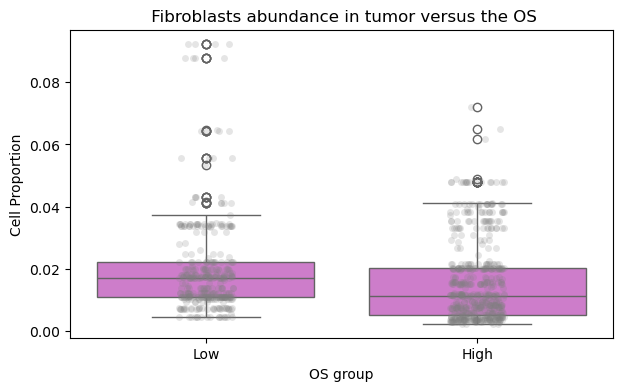

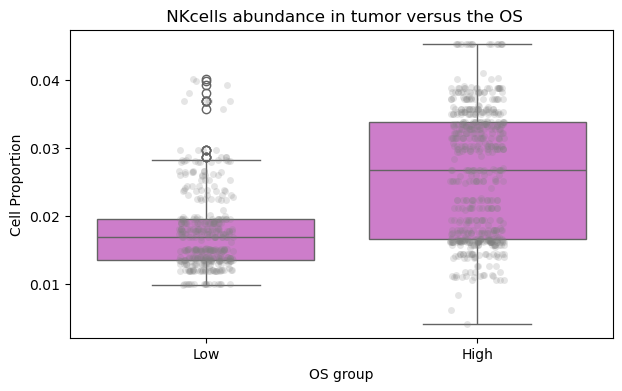

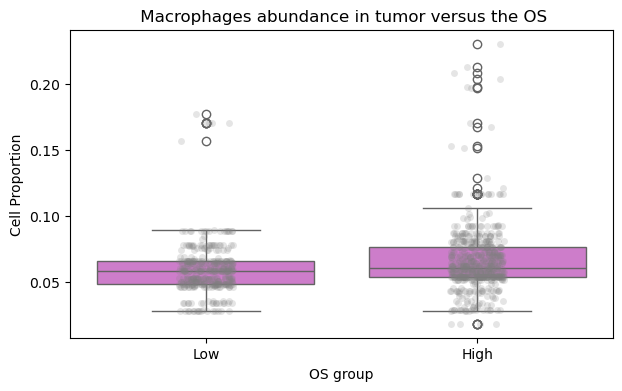

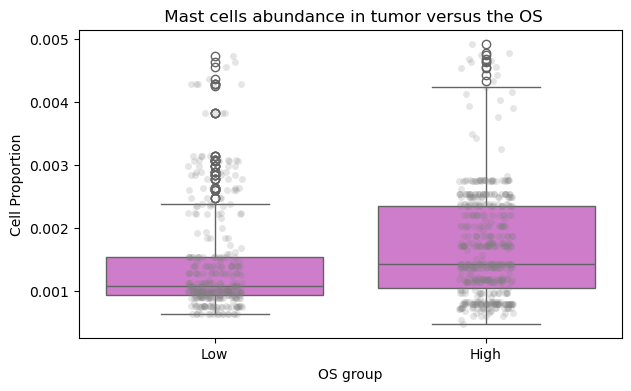

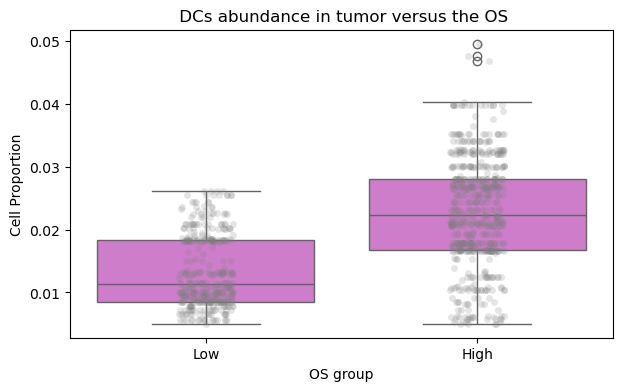

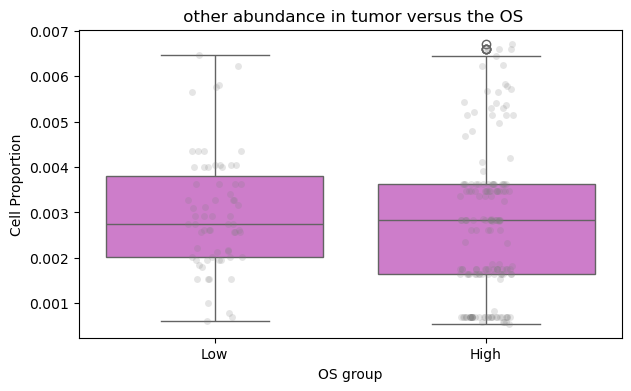

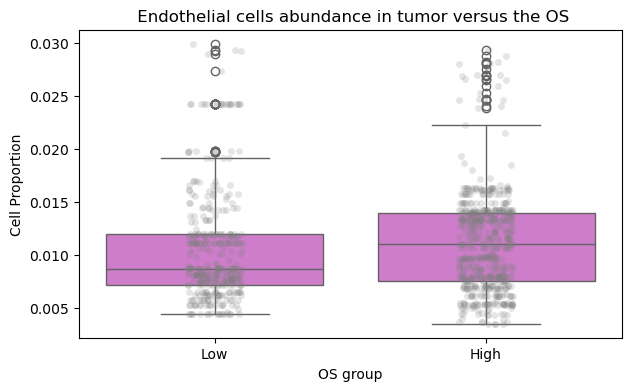

In [20]:
fibr_gene_expression_cell_abundance_stroma=fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_y"]=="tumor"]
for cell in cell_types:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="OS_HL_group",y=cell,data=fibr_gene_expression_cell_abundance_stroma, color='orchid')
    sns.stripplot(x="OS_HL_group", y=cell, data=fibr_gene_expression_cell_abundance_stroma, color='grey', alpha=0.2, jitter=True)
    plt.title(f" {cell} abundance in tumor versus the OS")
    plt.xlabel("OS group")
    plt.ylabel("Cell Proportion")
    plt.show()